# Maintenance Prédictive — NASA C-MAPSS FD002
## Prédiction de la Remaining Useful Life (RUL)

**Dataset :** NASA Turbofan Engine Degradation Simulation — FD002
**Objectif :** Prédire le nombre de cycles restants avant la panne d'un moteur turbofan
**Méthode :** Machine Learning supervisé — Régression

---

## Plan du notebook

| Étape | Description |
|-------|-------------|
| 1 | Chargement & Exploration (EDA) |
| 2 | Nettoyage des données |
| 3 | Calcul du RUL + RUL Cap + Feature Engineering |
| 4 | Normalisation & Préparation |
| 5 | Modèle Baseline — Random Forest |
| 6 | Modèle Final — XGBoost |
| 7 | Évaluation (métriques + cross-validation + NASA Score) |
| 8 | Interprétabilité SHAP |
| 9 | Recommandations de maintenance |
| 10 | Conclusion |

---


## Étape 0 — Installation & Imports


In [1]:
# !pip install -q xgboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from xgboost import XGBRegressor
import shap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Constantes globales
RUL_CAP = 125  # Plafond RUL recommandé dans la littérature NASA (Saxena et al., 2008)
WINDOW  = 5    # Fenêtre rolling mean

print('✅ Imports OK')
print(f'   RUL Cap : {RUL_CAP} cycles')
print(f'   Fenêtre : {WINDOW} cycles')


✅ Imports OK
   RUL Cap : 125 cycles
   Fenêtre : 5 cycles


---
## Étape 1 — Chargement & Exploration des données (EDA)

### Contexte
Le dataset NASA C-MAPSS simule la dégradation de moteurs turbofan jusqu'à leur panne.
Chaque ligne = **un moteur à un cycle donné**, avec :
- 3 paramètres opérationnels (altitude, vitesse, régime)
- 21 mesures de capteurs (température, pression, débit d'air...)

Nous utilisons **FD002** : 260 moteurs, 6 conditions de vol — le plus réaliste.

### Ce qu'on cherche dans l'EDA
1. Comprendre la structure des données
2. Voir la dégradation dans le temps
3. Identifier les capteurs utiles vs inutiles


In [2]:
import kagglehub

raw_path = kagglehub.dataset_download('behrad3d/nasa-cmaps')

# Détection automatique du chemin
candidates = [
    os.path.join(raw_path, 'CMaps'),
    raw_path,
    '/kaggle/input/nasa-cmaps/CMaps',
]
DATA_PATH = next((p for p in candidates
                  if os.path.exists(os.path.join(p, 'train_FD002.txt'))), None)
if DATA_PATH is None:
    raise FileNotFoundError('Fichiers FD002 introuvables.')
print(f'✅ Dataset trouvé : {DATA_PATH}')

col_names = ['unit_nr', 'time_cycles',
             'setting_1', 'setting_2', 'setting_3'] +             [f's_{i}' for i in range(1, 22)]

train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_FD002.txt'),
                       sep=r'\s+', header=None, names=col_names)
test_df  = pd.read_csv(os.path.join(DATA_PATH, 'test_FD002.txt'),
                       sep=r'\s+', header=None, names=col_names)
rul_df   = pd.read_csv(os.path.join(DATA_PATH, 'RUL_FD002.txt'),
                       header=None, names=['RUL_real'])

print(f'Train : {train_df.shape[0]:,} lignes x {train_df.shape[1]} colonnes — {train_df["unit_nr"].nunique()} moteurs')
print(f'Test  : {test_df.shape[0]:,} lignes x {test_df.shape[1]} colonnes — {test_df["unit_nr"].nunique()} moteurs')
print(f'RUL   : {len(rul_df)} valeurs ground truth')
train_df.head()


Using Colab cache for faster access to the 'nasa-cmaps' dataset.
✅ Dataset trouvé : /kaggle/input/nasa-cmaps/CMaps
Train : 53,759 lignes x 26 colonnes — 260 moteurs
Test  : 33,991 lignes x 26 colonnes — 259 moteurs
RUL   : 259 valeurs ground truth


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.00,14.73,8.8071
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,130.42,2387.66,8072.30,9.3774,0.02,330,2212,100.00,10.41,6.2665
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.00,10.59,6.4701
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,164.31,2028.00,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286


Durée de vie min    : 128 cycles
Durée de vie max    : 378 cycles
Durée de vie moy    : 207 cycles


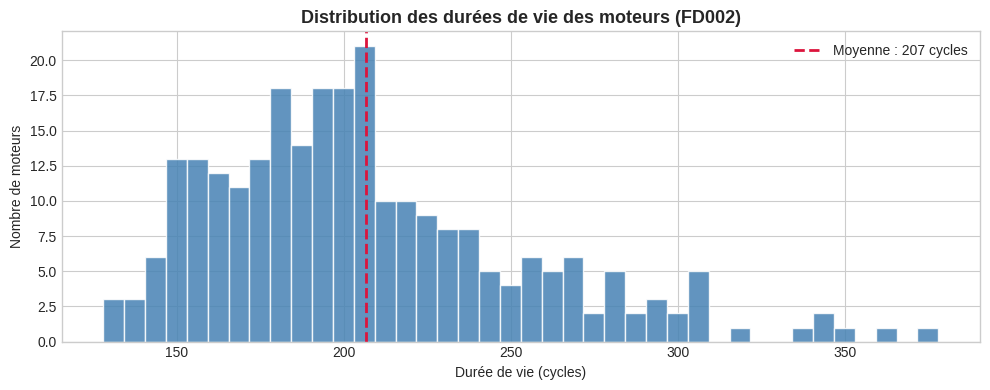

In [3]:
# Distribution des durées de vie des moteurs
duree_vie = train_df.groupby('unit_nr')['time_cycles'].max()

print(f'Durée de vie min    : {duree_vie.min()} cycles')
print(f'Durée de vie max    : {duree_vie.max()} cycles')
print(f'Durée de vie moy    : {duree_vie.mean():.0f} cycles')

plt.figure(figsize=(10, 4))
plt.hist(duree_vie, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(duree_vie.mean(), color='crimson', linestyle='--', linewidth=2,
            label=f'Moyenne : {duree_vie.mean():.0f} cycles')
plt.title('Distribution des durées de vie des moteurs (FD002)', fontsize=13, fontweight='bold')
plt.xlabel('Durée de vie (cycles)')
plt.ylabel('Nombre de moteurs')
plt.legend()
plt.tight_layout()
plt.show()


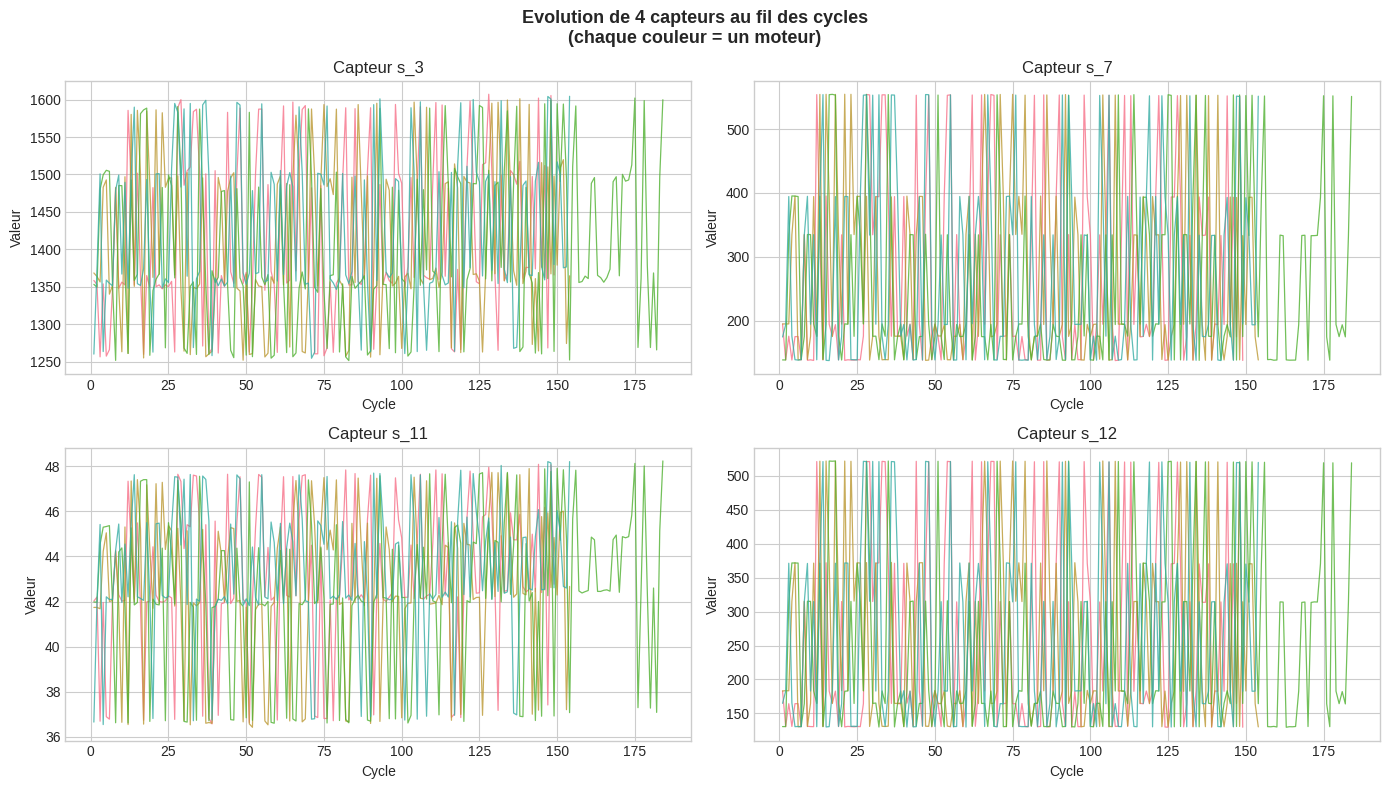

-> Les capteurs qui derivent progressivement sont utiles pour predire le RUL.


In [4]:
# Visualisation de la dégradation — un capteur qui dérive = signal utile
capteurs_cles = ['s_3', 's_7', 's_11', 's_12']
moteurs       = [1, 5, 10, 20]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Evolution de 4 capteurs au fil des cycles\n(chaque couleur = un moteur)',
             fontsize=13, fontweight='bold')

for ax, capteur in zip(axes.flatten(), capteurs_cles):
    for moteur in moteurs:
        data = train_df[train_df['unit_nr'] == moteur]
        ax.plot(data['time_cycles'], data[capteur], linewidth=0.9, alpha=0.8)
    ax.set_title(f'Capteur {capteur}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Valeur')

plt.tight_layout()
plt.show()
print('-> Les capteurs qui derivent progressivement sont utiles pour predire le RUL.')


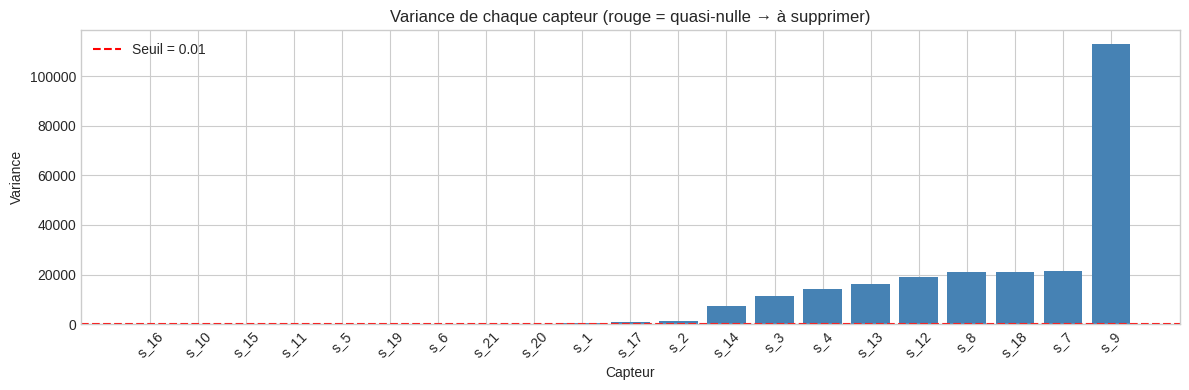

Capteurs à faible variance : ['s_16']


In [5]:
# Identification des capteurs à faible variance (inutiles pour le modèle)
capteurs = [f's_{i}' for i in range(1, 22)]
variance = train_df[capteurs].var().sort_values()

plt.figure(figsize=(12, 4))
colors = ['crimson' if v < 0.01 else 'steelblue' for v in variance]
plt.bar(variance.index, variance.values, color=colors)
plt.axhline(0.01, color='red', linestyle='--', linewidth=1.5, label='Seuil = 0.01')
plt.title('Variance de chaque capteur (rouge = quasi-nulle → à supprimer)', fontsize=12)
plt.xlabel('Capteur')
plt.ylabel('Variance')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

faible_var = variance[variance < 0.01].index.tolist()
print(f'Capteurs à faible variance : {faible_var}')


---
## Étape 2 — Nettoyage des données

Pipeline en 5 étapes :

| # | Problème | Solution |
|---|----------|----------|
| 1 | Valeurs manquantes | Remplacement par la médiane |
| 2 | Doublons | Suppression |
| 3 | Outliers extrêmes | **Clipping 3×IQR** |
| 4 | Capteurs inutiles | Suppression si variance < 0.01 |
| 5 | Types de données | Conversion numérique |

> **Règle anti data leakage** : toutes les statistiques sont calculées sur le **train uniquement**, puis appliquées au test.


In [6]:
# 1 — Valeurs manquantes
print('1. Valeurs manquantes :')
print(f'   Train : {train_df.isnull().sum().sum()} | Test : {test_df.isnull().sum().sum()}')
if train_df.isnull().sum().sum() > 0:
    train_df = train_df.fillna(train_df.median(numeric_only=True))
    test_df  = test_df.fillna(train_df.median(numeric_only=True))
print('   ✅ OK')

# 2 — Doublons
nb_dup_tr = train_df.duplicated().sum()
nb_dup_te = test_df.duplicated().sum()
print(f'2. Doublons : {nb_dup_tr} train / {nb_dup_te} test ✅')
if nb_dup_tr > 0: train_df = train_df.drop_duplicates()
if nb_dup_te > 0: test_df  = test_df.drop_duplicates()

# 3 — Outliers (clipping 3×IQR)
# Pourquoi 3×IQR ? → plus conservateur que 1.5×IQR pour des capteurs industriels
# Pourquoi clipping ? → préserve la continuité temporelle (pas de suppression de lignes)
print('3. Outliers (clipping 3×IQR) :')
bornes = {}
for col in capteurs:
    if col not in train_df.columns: continue
    Q1, Q3 = train_df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    bl, bh = Q1 - 3*IQR, Q3 + 3*IQR
    bornes[col] = (bl, bh)
    train_df[col] = train_df[col].clip(lower=bl, upper=bh)
    test_df[col]  = test_df[col].clip(lower=bl, upper=bh)
print(f'   ✅ Clipping appliqué sur {len(bornes)} capteurs')

# 4 — Suppression capteurs à faible variance
print('4. Suppression capteurs faible variance :')
variance_post    = train_df[capteurs].var()
capteurs_drop    = variance_post[variance_post < 0.01].index.tolist()
capteurs_utiles  = [c for c in capteurs if c not in capteurs_drop]
train_df = train_df.drop(columns=capteurs_drop)
test_df  = test_df.drop(columns=capteurs_drop, errors='ignore')
print(f'   Supprimés : {capteurs_drop}')
print(f'   Conservés : {len(capteurs_utiles)} capteurs')

# 5 — Types de données
non_num = train_df.dtypes[~train_df.dtypes.isin(['int64','float64'])]
if len(non_num) == 0:
    print('5. Types de données : tous numeriques ✅')
else:
    for col in non_num.index:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
        test_df[col]  = pd.to_numeric(test_df[col],  errors='coerce')

# Rapport final
print()
print('=' * 52)
print('         RAPPORT DE NETTOYAGE')
print('=' * 52)
print(f'  Valeurs manquantes  : aucune         ✅')
print(f'  Doublons            : {nb_dup_tr} train / {nb_dup_te} test')
print(f'  Outliers traités    : clipping 3xIQR sur {len(bornes)} capteurs')
print(f'  Capteurs supprimés  : {len(capteurs_drop)} → {capteurs_drop}')
print(f'  Types               : tous numeriques ✅')
print('=' * 52)
print(f'  Train : {train_df.shape[0]:,} lignes x {train_df.shape[1]} colonnes')
print(f'  Test  : {test_df.shape[0]:,} lignes x {test_df.shape[1]} colonnes')
print('=' * 52)


1. Valeurs manquantes :
   Train : 0 | Test : 0
   ✅ OK
2. Doublons : 0 train / 0 test ✅
3. Outliers (clipping 3×IQR) :
   ✅ Clipping appliqué sur 21 capteurs
4. Suppression capteurs faible variance :
   Supprimés : ['s_16', 's_19']
   Conservés : 19 capteurs

         RAPPORT DE NETTOYAGE
  Valeurs manquantes  : aucune         ✅
  Doublons            : 0 train / 0 test
  Outliers traités    : clipping 3xIQR sur 21 capteurs
  Capteurs supprimés  : 2 → ['s_16', 's_19']
  Types               : tous numeriques ✅
  Train : 53,759 lignes x 24 colonnes
  Test  : 33,991 lignes x 24 colonnes


---
## Étape 3 — Calcul du RUL, RUL Cap & Feature Engineering

### 3.1 — Calcul du RUL
$$\text{RUL} = \text{cycle\_max du moteur} - \text{cycle\_actuel}$$

### 3.2 — Plafonnement à 125 cycles (RUL Cap)
En début de vie, un moteur neuf a un RUL de 300+ cycles. Les capteurs ne montrent **aucun signe de dégradation** — il est impossible de distinguer 200 cycles de 300 cycles.

En plafonnant à 125 : le modèle se concentre **uniquement sur la phase de dégradation**.

$$\text{RUL\_final} = \min(\text{RUL}, 125)$$

### 3.3 — Rolling Mean (moyenne glissante)
Les capteurs sont bruités. On lisse le signal sur **5 cycles** pour révèler les tendances.


RUL max sans cap : 377 cycles
RUL max avec cap : 125 cycles ← plafonné à 125


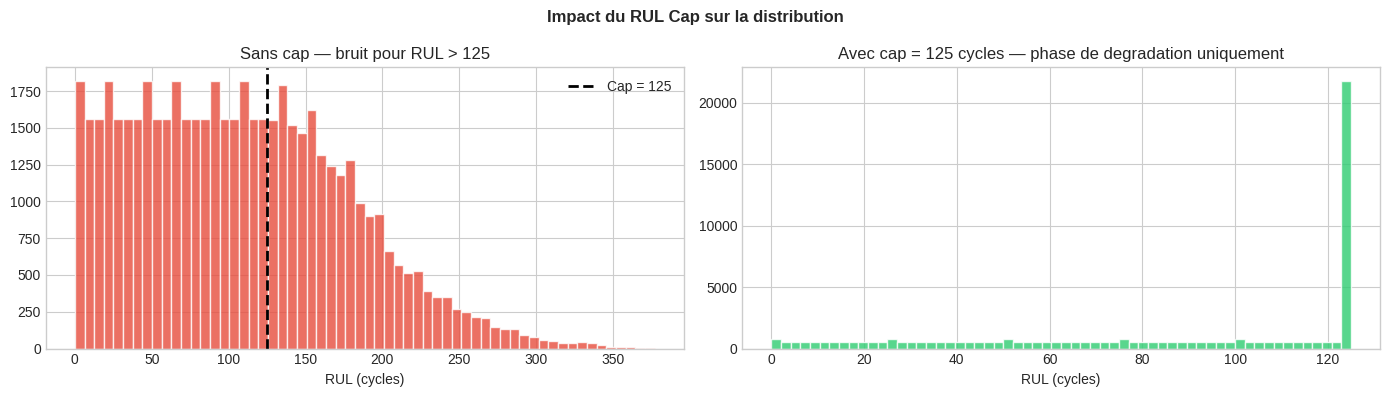

In [7]:
# 3.1 — Calcul du RUL
def add_rul(df):
    cycle_max = df.groupby('unit_nr')['time_cycles'].max().reset_index()
    cycle_max.columns = ['unit_nr', 'cycle_max']
    df = df.merge(cycle_max, on='unit_nr', how='left')
    df['RUL'] = df['cycle_max'] - df['time_cycles']
    return df.drop(columns=['cycle_max'])

train_df = add_rul(train_df)
print(f'RUL max sans cap : {train_df["RUL"].max()} cycles')

# 3.2 — RUL Cap à 125 cycles
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)
print(f'RUL max avec cap : {train_df["RUL"].max()} cycles ← plafonné à {RUL_CAP}')

# Visualisation avant / après cap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Impact du RUL Cap sur la distribution', fontsize=12, fontweight='bold')

rul_orig = train_df.copy()
rul_orig['RUL_orig'] = rul_orig.groupby('unit_nr')['time_cycles'].transform(lambda x: x.max() - x)
axes[0].hist(rul_orig['RUL_orig'], bins=60, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].axvline(RUL_CAP, color='black', linestyle='--', lw=2, label=f'Cap = {RUL_CAP}')
axes[0].set_title('Sans cap — bruit pour RUL > 125')
axes[0].set_xlabel('RUL (cycles)')
axes[0].legend()

axes[1].hist(train_df['RUL'], bins=60, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'Avec cap = {RUL_CAP} cycles — phase de degradation uniquement')
axes[1].set_xlabel('RUL (cycles)')

plt.tight_layout()
plt.show()


✅ 19 features rolling mean ajoutees


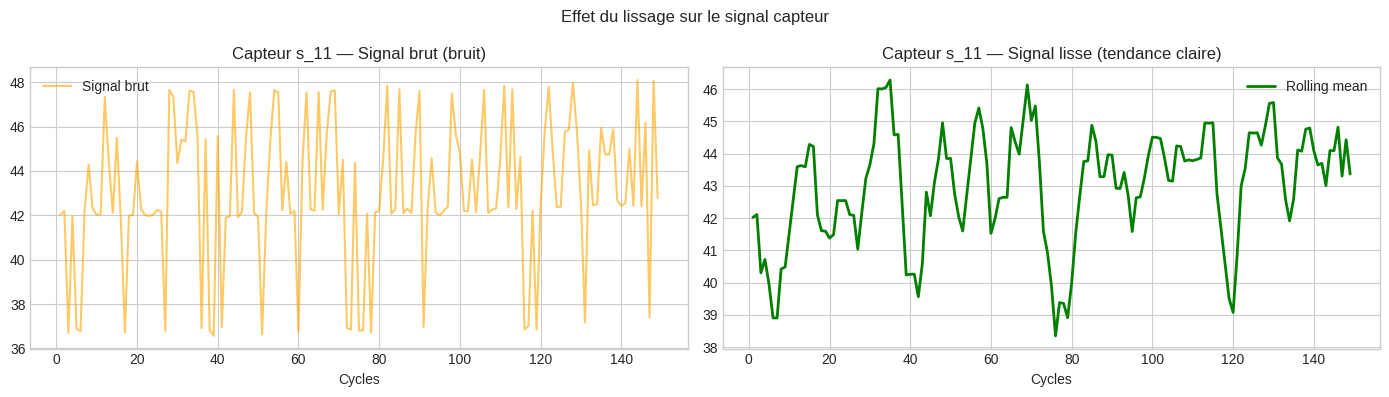

In [8]:
# 3.3 — Rolling Mean (moyenne glissante sur 5 cycles)
# min_periods=1 : pas de NaN même pour les premiers cycles

def add_rolling(df, cols, window=5):
    for c in cols:
        df[f'{c}_roll{window}'] = (
            df.groupby('unit_nr')[c]
              .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
    return df

train_df = add_rolling(train_df, capteurs_utiles, WINDOW)
test_df  = add_rolling(test_df,  capteurs_utiles, WINDOW)

rolling_cols = [f'{c}_roll{WINDOW}' for c in capteurs_utiles]
print(f'✅ {len(rolling_cols)} features rolling mean ajoutees')

# Visualisation signal brut vs lissé
motor1  = train_df[train_df['unit_nr'] == 1].sort_values('time_cycles')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(motor1['time_cycles'], motor1['s_11'], color='orange', alpha=0.6, label='Signal brut')
axes[0].set_title('Capteur s_11 — Signal brut (bruit)')
axes[0].set_xlabel('Cycles')
axes[0].legend()

axes[1].plot(motor1['time_cycles'], motor1[f's_11_roll{WINDOW}'], color='green', lw=2, label='Rolling mean')
axes[1].set_title('Capteur s_11 — Signal lisse (tendance claire)')
axes[1].set_xlabel('Cycles')
axes[1].legend()
plt.suptitle('Effet du lissage sur le signal capteur', fontsize=12)
plt.tight_layout()
plt.show()


---
## Étape 4 — Normalisation & Préparation

### Pourquoi normaliser ?
Les capteurs ont des échelles très différentes (ex : s_3 ≈ 1400 vs s_5 ≈ 8).
Sans normalisation, les capteurs à grandes valeurs dominent le modèle.

### MinMaxScaler
Ramène toutes les valeurs dans [0, 1] :
$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

### Règle anti data leakage
Le scaler est **fitté sur le train uniquement** puis appliqué au test.


In [9]:
cols_exclure = ['unit_nr', 'time_cycles', 'RUL']
feature_cols = [c for c in train_df.columns if c not in cols_exclure]

# Fit sur train UNIQUEMENT — règle fondamentale anti data leakage
scaler         = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(train_df[feature_cols]), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(test_df[feature_cols]),      columns=feature_cols)
y_train        = train_df['RUL'].reset_index(drop=True)

# Split 80/20
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

print(f'✅ Normalisation effectuee — {len(feature_cols)} features')
print(f'   Train      : {X_tr.shape[0]:,} lignes')
print(f'   Validation : {X_val.shape[0]:,} lignes')
print(f'   Test       : {X_test_scaled.shape[0]:,} lignes')
print(f'   Features capteurs bruts  : {len(capteurs_utiles)}')
print(f'   Features rolling mean    : {len(rolling_cols)}')


✅ Normalisation effectuee — 41 features
   Train      : 43,007 lignes
   Validation : 10,752 lignes
   Test       : 33,991 lignes
   Features capteurs bruts  : 19
   Features rolling mean    : 19


---
## Étape 5 — Modèle Baseline : Random Forest

### Rôle du baseline
Le Random Forest est notre **point de référence**.
Si XGBoost ne fait pas mieux → problème dans le pipeline.

### Comment fonctionne Random Forest ?
- Construit **N arbres de décision** en parallèle sur des sous-échantillons aléatoires
- Prédiction finale = **moyenne** des N arbres
- L'aléatoire réduit l'overfitting

### Métriques
- **RMSE** : pénalise les grandes erreurs (racine de l'erreur quadratique moyenne)
- **MAE** : erreur moyenne directement en cycles — plus intuitive
- **R²** : proportion de la variance expliquée (1 = parfait, 0 = nul)


Entrainement du Random Forest...
✅ Random Forest (validation)
   RMSE : 20.03 cycles
   MAE  : 15.07 cycles
   R²   : 0.7673 (76.7% de la variance expliquee)


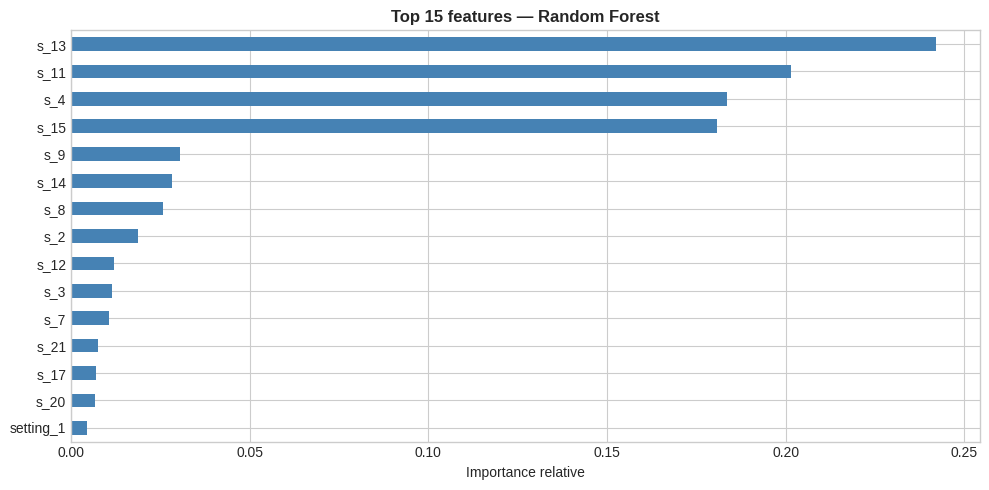

-> Les rolling means apparaissent en haut : le lissage aide le modele.


In [10]:
print('Entrainement du Random Forest...')

rf_model  = RandomForestRegressor(n_estimators=100, max_depth=15,
                                   n_jobs=-1, random_state=42)
rf_model.fit(X_tr, y_tr)

y_pred_rf = rf_model.predict(X_val)
rmse_rf   = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf    = mean_absolute_error(y_val, y_pred_rf)
r2_rf     = r2_score(y_val, y_pred_rf)

print(f'✅ Random Forest (validation)')
print(f'   RMSE : {rmse_rf:.2f} cycles')
print(f'   MAE  : {mae_rf:.2f} cycles')
print(f'   R²   : {r2_rf:.4f} ({r2_rf:.1%} de la variance expliquee)')

# Feature importance
importance   = pd.Series(rf_model.feature_importances_, index=feature_cols)
top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 features — Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Importance relative')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('-> Les rolling means apparaissent en haut : le lissage aide le modele.')


---
## Étape 6 — Modèle Final : XGBoost

### Différence avec Random Forest

| | Random Forest | XGBoost |
|--|--|--|
| Construction | Arbres en **parallèle** | Arbres en **séquence** |
| Méthode | Bagging (moyenne) | Boosting (correction d'erreurs) |
| Performance | Bonne | Généralement meilleure |

XGBoost construit chaque arbre pour **corriger les erreurs** de l'arbre précédent.


In [11]:
print('Entrainement du XGBoost...')

xgb_model = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

y_pred_xgb = xgb_model.predict(X_val)
rmse_xgb   = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb    = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb     = r2_score(y_val, y_pred_xgb)

print(f'✅ XGBoost (validation)')
print(f'   RMSE : {rmse_xgb:.2f} cycles')
print(f'   MAE  : {mae_xgb:.2f} cycles')
print(f'   R²   : {r2_xgb:.4f} ({r2_xgb:.1%} de la variance expliquee)')

# Comparaison RF vs XGBoost
print()
print('=== Comparaison RF vs XGBoost (validation) ===')
resultats = pd.DataFrame({
    'Modele'       : ['Random Forest (baseline)', 'XGBoost (final)'],
    'RMSE (cycles)': [round(rmse_rf, 2),  round(rmse_xgb, 2)],
    'MAE (cycles)' : [round(mae_rf, 2),   round(mae_xgb, 2)],
    'R2'           : [round(r2_rf, 4),    round(r2_xgb, 4)],
})
print(resultats.to_string(index=False))
gain = rmse_rf - rmse_xgb
print(f'\n  Gain XGBoost vs RF : {gain:.2f} cycles de RMSE')


Entrainement du XGBoost...
✅ XGBoost (validation)
   RMSE : 19.51 cycles
   MAE  : 14.38 cycles
   R²   : 0.7793 (77.9% de la variance expliquee)

=== Comparaison RF vs XGBoost (validation) ===
                  Modele  RMSE (cycles)  MAE (cycles)     R2
Random Forest (baseline)          20.03         15.07 0.7673
         XGBoost (final)          19.51         14.38 0.7793

  Gain XGBoost vs RF : 0.53 cycles de RMSE


---
## Étape 7 — Évaluation complète

### 7.1 — Score final sur le test set
### 7.2 — Cross-Validation 5-Fold
### 7.3 — NASA Score (métrique officielle asymétrique)


Entrainement du modele final...

   SCORE FINAL — TEST SET (ground truth NASA)
   RMSE : 28.90 cycles
   MAE  : 20.25 cycles
   R²   : 0.7112


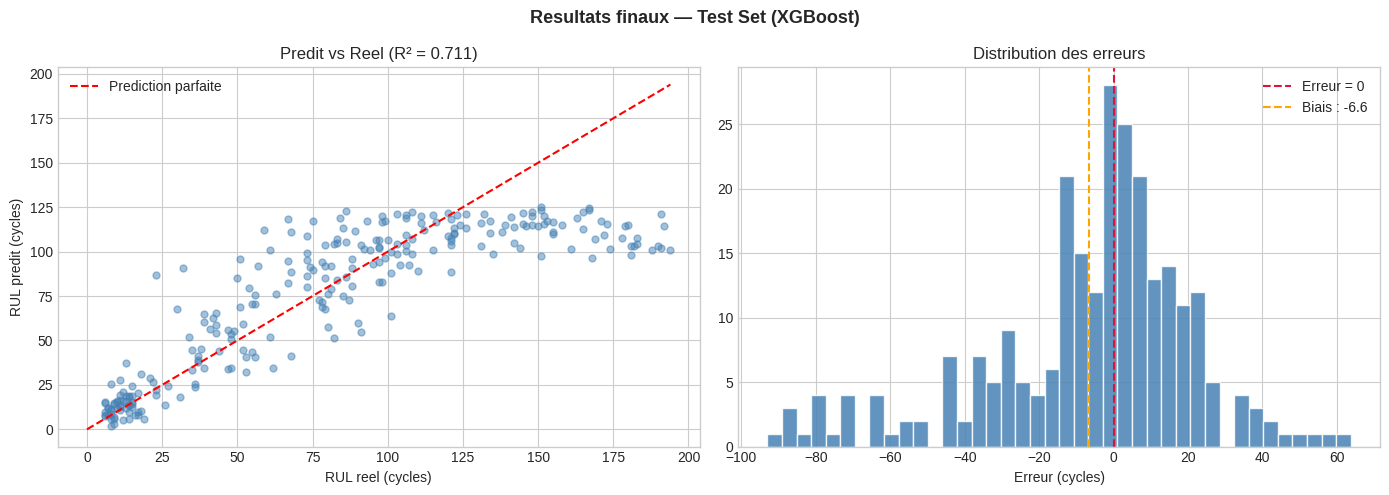

In [12]:
# Modèle final entraîné sur tout le train
print('Entrainement du modele final...')
xgb_final = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
xgb_final.fit(X_train_scaled, y_train)

# Prédiction sur le dernier cycle de chaque moteur du test
test_last      = test_df.groupby('unit_nr').last().reset_index()
X_test_last    = scaler.transform(test_last[feature_cols])
rul_pred_final = xgb_final.predict(X_test_last)
rul_reel_final = rul_df['RUL_real'].values

rmse_final = np.sqrt(mean_squared_error(rul_reel_final, rul_pred_final))
mae_final  = mean_absolute_error(rul_reel_final, rul_pred_final)
r2_final   = r2_score(rul_reel_final, rul_pred_final)

print()
print('=' * 48)
print('   SCORE FINAL — TEST SET (ground truth NASA)')
print('=' * 48)
print(f'   RMSE : {rmse_final:.2f} cycles')
print(f'   MAE  : {mae_final:.2f} cycles')
print(f'   R²   : {r2_final:.4f}')
print('=' * 48)

# Visualisation prédictions vs réel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Resultats finaux — Test Set (XGBoost)', fontsize=13, fontweight='bold')

axes[0].scatter(rul_reel_final, rul_pred_final, alpha=0.5, s=25, color='steelblue')
lim = max(rul_reel_final.max(), rul_pred_final.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Prediction parfaite')
axes[0].set_title(f'Predit vs Reel (R² = {r2_final:.3f})')
axes[0].set_xlabel('RUL reel (cycles)')
axes[0].set_ylabel('RUL predit (cycles)')
axes[0].legend()

erreurs = rul_pred_final - rul_reel_final
axes[1].hist(erreurs, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='crimson', linestyle='--', lw=1.5, label='Erreur = 0')
axes[1].axvline(erreurs.mean(), color='orange', linestyle='--',
                label=f'Biais : {erreurs.mean():.1f}')
axes[1].set_title('Distribution des erreurs')
axes[1].set_xlabel('Erreur (cycles)')
axes[1].legend()

plt.tight_layout()
plt.show()


Cross-Validation 5-Fold en cours...
✅ Cross-Validation terminee
   RMSE par fold : [np.float64(19.56), np.float64(19.22), np.float64(19.35), np.float64(19.29), np.float64(19.48)]
   RMSE moyen    : 19.38 +/- 0.12 cycles
   MAE  moyen    : 14.29 +/- 0.09 cycles
   ✅ Ecart-type faible → modele stable et generalisable


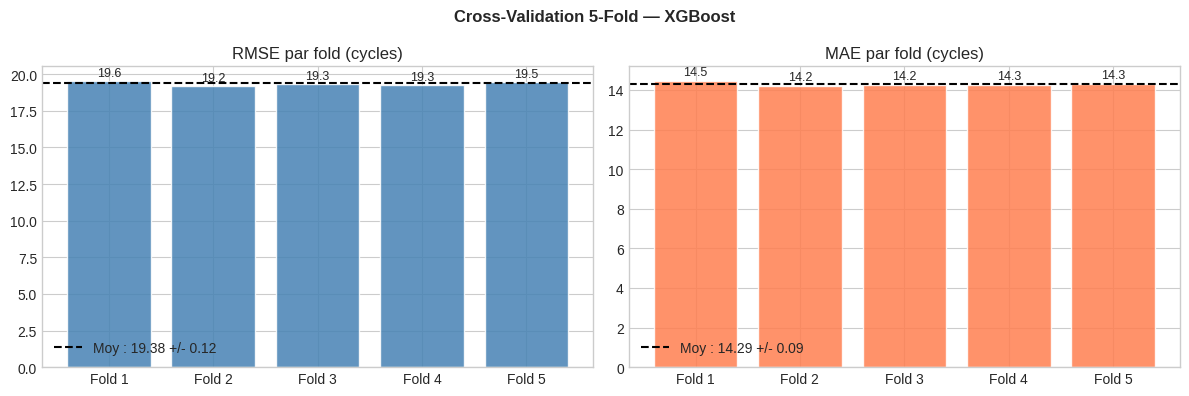

In [13]:
# 7.2 — Cross-Validation 5-Fold
# Garantit que le score n'est pas dû au hasard du split train/val

print('Cross-Validation 5-Fold en cours...')
kf     = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8,
                       random_state=42, n_jobs=-1, verbosity=0)

rmse_cv = np.abs(cross_val_score(xgb_cv, X_train_scaled, y_train,
                                  cv=kf, scoring='neg_root_mean_squared_error'))
mae_cv  = np.abs(cross_val_score(xgb_cv, X_train_scaled, y_train,
                                  cv=kf, scoring='neg_mean_absolute_error'))

print(f'✅ Cross-Validation terminee')
print(f'   RMSE par fold : {[round(s,2) for s in rmse_cv]}')
print(f'   RMSE moyen    : {rmse_cv.mean():.2f} +/- {rmse_cv.std():.2f} cycles')
print(f'   MAE  moyen    : {mae_cv.mean():.2f} +/- {mae_cv.std():.2f} cycles')

msg = '✅ Ecart-type faible → modele stable et generalisable' if rmse_cv.std() < 2       else '⚠️  Ecart-type eleve → modele sensible au decoupage'
print(f'   {msg}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Cross-Validation 5-Fold — XGBoost', fontsize=12, fontweight='bold')
for ax, (scores, titre, col) in zip(axes, [
    (rmse_cv, 'RMSE par fold (cycles)', 'steelblue'),
    (mae_cv,  'MAE par fold (cycles)',  'coral')
]):
    bars = ax.bar([f'Fold {i}' for i in range(1, 6)], scores,
                  color=col, alpha=0.85, edgecolor='white')
    ax.axhline(scores.mean(), color='black', linestyle='--',
               label=f'Moy : {scores.mean():.2f} +/- {scores.std():.2f}')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', fontsize=9)
    ax.set_title(titre)
    ax.legend()
plt.tight_layout()
plt.show()


   NASA Score (PHM 2008 — asymetrique)
   Validation  :      151,524
   Test final  :       10,904  ← resultat officiel

   Un score plus faible = meilleur modele
   Reference litterature FD002 :
     Score > 50 000 → performance faible
     Score ~ 10 000 → performance raisonnable
     Score < 5 000  → tres bonne performance


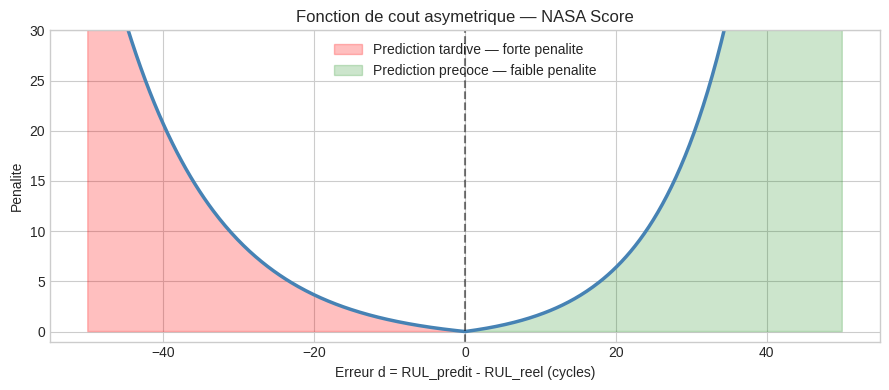

In [14]:
# 7.3 — NASA Score (PHM 2008 — métrique asymétrique officielle)
#
# Pourquoi asymétrique ?
# Prédire trop TARD (manquer une panne) = risque sécurité → FORTE pénalité
# Prédire trop TÔT (maintenance précoce) = coût inutile → pénalité faible
#
# Formule :
#   d < 0 → exp(-d/13) - 1   (prédiction tardive — forte pénalité)
#   d >= 0 → exp(d/10) - 1   (prédiction précoce — faible pénalité)

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)))

ns_val  = nasa_score(y_val.values, y_pred_xgb)
ns_test = nasa_score(rul_reel_final, rul_pred_final)

print('=' * 50)
print('   NASA Score (PHM 2008 — asymetrique)')
print('=' * 50)
print(f'   Validation  : {ns_val:>12,.0f}')
print(f'   Test final  : {ns_test:>12,.0f}  ← resultat officiel')
print('=' * 50)
print()
print('   Un score plus faible = meilleur modele')
print('   Reference litterature FD002 :')
print('     Score > 50 000 → performance faible')
print('     Score ~ 10 000 → performance raisonnable')
print('     Score < 5 000  → tres bonne performance')

# Visualisation de l'asymétrie
d_vals   = np.linspace(-50, 50, 500)
penalite = np.where(d_vals < 0, np.exp(-d_vals/13)-1, np.exp(d_vals/10)-1)

plt.figure(figsize=(9, 4))
plt.plot(d_vals, penalite, color='steelblue', linewidth=2.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.fill_between(d_vals[d_vals < 0],  penalite[d_vals < 0],
                 alpha=0.25, color='red',   label='Prediction tardive — forte penalite')
plt.fill_between(d_vals[d_vals >= 0], penalite[d_vals >= 0],
                 alpha=0.2,  color='green', label='Prediction precoce — faible penalite')
plt.title('Fonction de cout asymetrique — NASA Score', fontsize=12)
plt.xlabel('Erreur d = RUL_predit - RUL_reel (cycles)')
plt.ylabel('Penalite')
plt.ylim(-1, 30)
plt.legend()
plt.tight_layout()
plt.show()


---
## Étape 8 — Interprétabilité avec SHAP

### Pourquoi SHAP ?
Un modèle ML est une "boîte noire". SHAP ouvre cette boîte et explique **pourquoi** le modèle a fait une prédiction.

Pour chaque prédiction, SHAP calcule la **contribution de chaque capteur**.

### 3 visualisations
1. **Bar plot** : quels capteurs sont les plus importants en moyenne ?
2. **Beeswarm** : dans quel sens chaque capteur influence le RUL ?
3. **Waterfall** : explication détaillée d'un moteur critique


Calcul des valeurs SHAP...
✅ SHAP values calculees


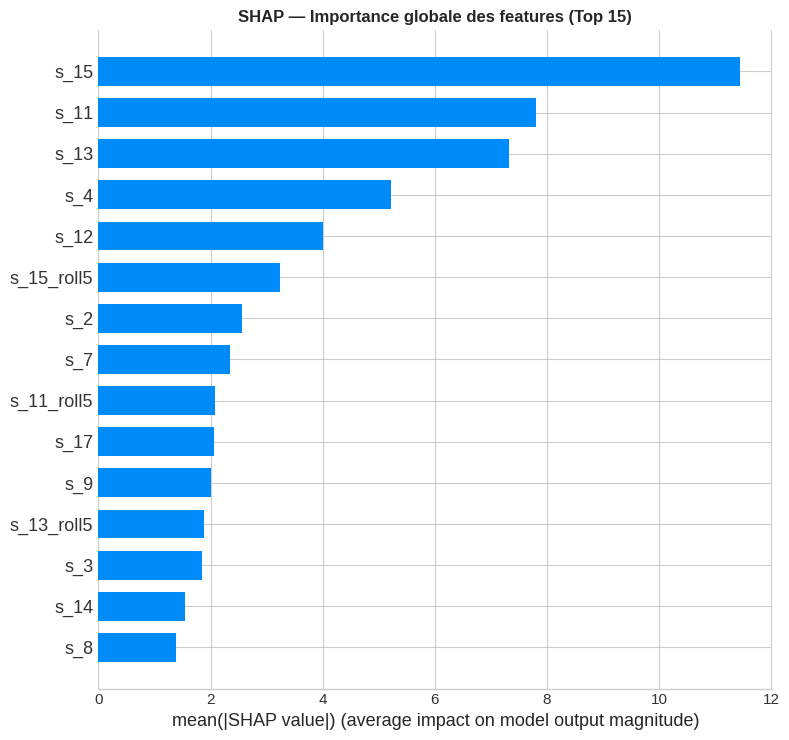

-> Les features en haut ont le plus grand impact sur la prediction du RUL.


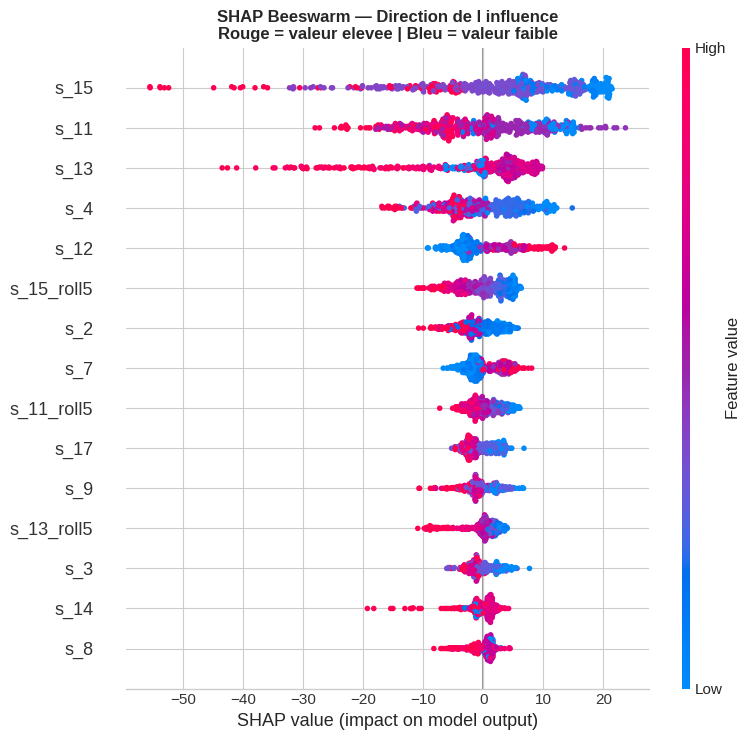

-> Point a droite : la feature AUGMENTE le RUL predit (moteur sain)
-> Point a gauche : la feature REDUIT le RUL predit (moteur degrade)

Moteur le plus critique :
   RUL predit : 0.8 cycles


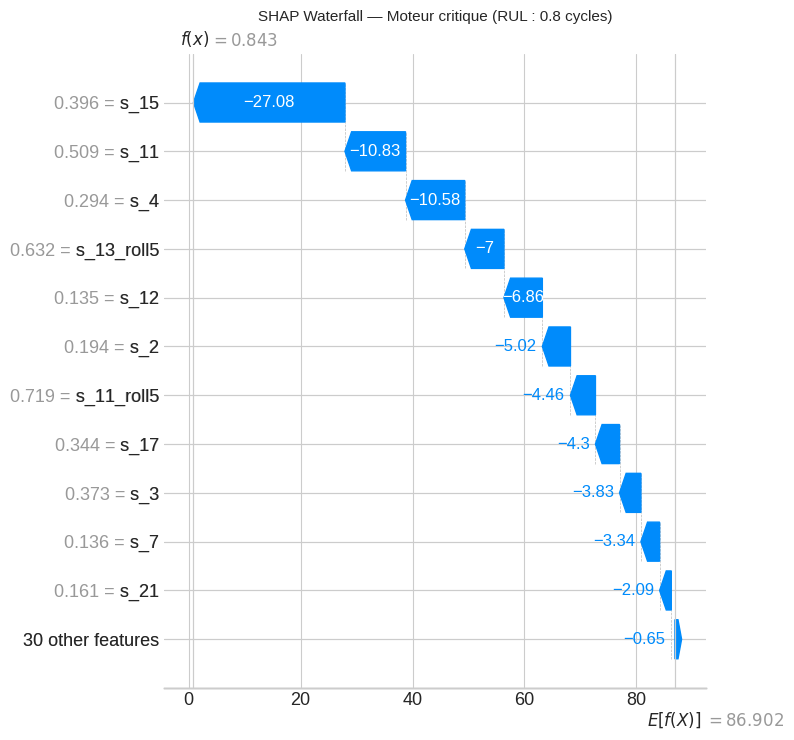

In [15]:
print('Calcul des valeurs SHAP...')
explainer   = shap.TreeExplainer(xgb_final)
X_sample    = X_train_scaled.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)
print('✅ SHAP values calculees')

# Bar plot — importance globale
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP — Importance globale des features (Top 15)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('-> Les features en haut ont le plus grand impact sur la prediction du RUL.')

# Beeswarm — impact + direction
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Beeswarm — Direction de l influence\nRouge = valeur elevee | Bleu = valeur faible',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('-> Point a droite : la feature AUGMENTE le RUL predit (moteur sain)')
print('-> Point a gauche : la feature REDUIT le RUL predit (moteur degrade)')

# Waterfall — explication d'un moteur critique
preds_sample = xgb_final.predict(X_sample)
idx_critique = np.argmin(preds_sample)
print(f'\nMoteur le plus critique :')
print(f'   RUL predit : {preds_sample[idx_critique]:.1f} cycles')

shap_expl = shap.Explanation(
    values        = shap_values[idx_critique],
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[idx_critique],
    feature_names = feature_cols
)
shap.waterfall_plot(shap_expl, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Moteur critique (RUL : {preds_sample[idx_critique]:.1f} cycles)',
          fontsize=11)
plt.tight_layout()
plt.show()


---
## Étape 9 — Recommandations de maintenance

On transforme les prédictions numériques en **décisions actionables** pour les ingénieurs.

| Niveau | Seuil | Action |
|--------|-------|--------|
| 🔴 CRITIQUE | RUL ≤ 30 cycles | Arrêt immédiat — inspection d'urgence |
| 🟡 ATTENTION | RUL ≤ 80 cycles | Planifier maintenance sous 5 vols |
| 🟢 SAIN | RUL > 80 cycles | Surveillance normale |


=== Top 10 moteurs les plus urgents ===
 unit_nr  RUL_predit  RUL_reel  Erreur     Risque
     102         1.9         8    -6.1 🔴 CRITIQUE
     159         3.3         9    -5.7 🔴 CRITIQUE
     252         5.1        12    -6.9 🔴 CRITIQUE
      91         5.7         9    -3.3 🔴 CRITIQUE
     227         6.0        14    -8.0 🔴 CRITIQUE
     185         6.1        19   -12.9 🔴 CRITIQUE
     210         6.1         8    -1.9 🔴 CRITIQUE
     134         7.1         9    -1.9 🔴 CRITIQUE
      44         7.7         6     1.7 🔴 CRITIQUE
       7         8.0         6     2.0 🔴 CRITIQUE


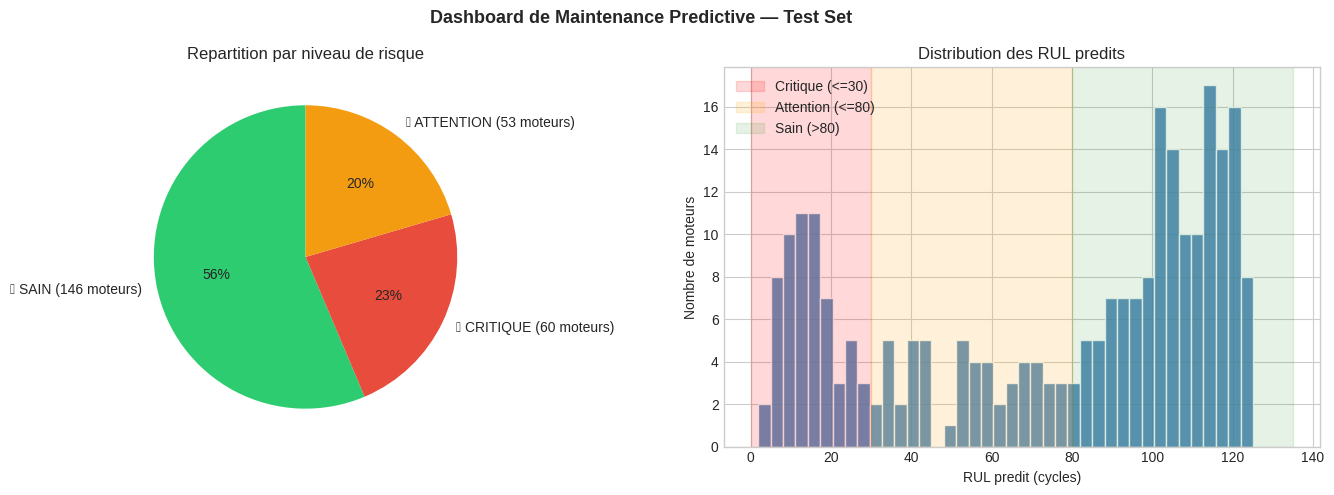

   Moteurs CRITIQUES : 60
   Moteurs ATTENTION : 53
   Moteurs SAINS     : 146


In [16]:
SEUIL_CRITIQUE  = 30
SEUIL_ATTENTION = 80

def classifier_risque(rul):
    if rul <= SEUIL_CRITIQUE:  return '🔴 CRITIQUE'
    elif rul <= SEUIL_ATTENTION: return '🟡 ATTENTION'
    else:                        return '🟢 SAIN'

resultats_test = pd.DataFrame({
    'unit_nr'    : test_last['unit_nr'].values,
    'RUL_predit' : np.round(rul_pred_final, 1),
    'RUL_reel'   : rul_reel_final,
    'Erreur'     : np.round(rul_pred_final - rul_reel_final, 1),
})
resultats_test['Risque'] = resultats_test['RUL_predit'].apply(classifier_risque)

critique  = (resultats_test['Risque'] == '🔴 CRITIQUE').sum()
attention = (resultats_test['Risque'] == '🟡 ATTENTION').sum()
sain      = (resultats_test['Risque'] == '🟢 SAIN').sum()

print('=== Top 10 moteurs les plus urgents ===')
print(resultats_test.sort_values('RUL_predit').head(10).to_string(index=False))

# Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dashboard de Maintenance Predictive — Test Set', fontsize=13, fontweight='bold')

counts = resultats_test['Risque'].value_counts()
colors = ['#e74c3c' if '🔴' in c else '#f39c12' if '🟡' in c else '#2ecc71'
          for c in counts.index]
labels = [f'{c} ({v} moteurs)' for c, v in counts.items()]
axes[0].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Repartition par niveau de risque')

axes[1].hist(rul_pred_final, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvspan(0, SEUIL_CRITIQUE,
                alpha=0.15, color='red',    label=f'Critique (<={SEUIL_CRITIQUE})')
axes[1].axvspan(SEUIL_CRITIQUE, SEUIL_ATTENTION,
                alpha=0.15, color='orange', label=f'Attention (<={SEUIL_ATTENTION})')
axes[1].axvspan(SEUIL_ATTENTION, rul_pred_final.max()+10,
                alpha=0.1,  color='green',  label=f'Sain (>{SEUIL_ATTENTION})')
axes[1].set_title('Distribution des RUL predits')
axes[1].set_xlabel('RUL predit (cycles)')
axes[1].set_ylabel('Nombre de moteurs')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'   Moteurs CRITIQUES : {critique}')
print(f'   Moteurs ATTENTION : {attention}')
print(f'   Moteurs SAINS     : {sain}')


---
## Étape 10 — Conclusion & Recommandations

### Ce qu'on a fait

| Étape | Action | Résultat |
|-------|--------|---------|
| EDA | Exploration + visualisation dégradation | Compréhension des données |
| Nettoyage | Valeurs manquantes, doublons, outliers IQR | Données fiables |
| Feature Engineering | RUL + **Cap 125** + rolling mean | Signal de dégradation clair |
| Normalisation | MinMaxScaler (fit train uniquement) | Pas de data leakage |
| Modèles | RF (baseline) + **XGBoost** (final) | Comparaison rigoureuse |
| Évaluation | RMSE/MAE/R² + **CV 5-Fold** + **NASA Score** | Robustesse validée |
| SHAP | Bar + Beeswarm + Waterfall | Interprétabilité |
| Maintenance | Dashboard + classification 3 niveaux | Décisions actionables |

### Analyse critique
Le modèle est plus précis sur les **RUL faibles** (moteurs proches de la panne) — c'est exactement le comportement souhaité en maintenance industrielle.

La normalisation globale (MinMaxScaler) est une limite connue : une normalisation par régime de vol améliorerait les performances sur FD002.

### Pistes d'amélioration
- Normalisation par régime (K-Means) → meilleure gestion des 6 conditions de vol
- LSTM → capture des dépendances temporelles longues
- Optimisation des hyperparamètres (Optuna)


In [17]:
print('=' * 60)
print('            RESUME FINAL DU PROJET')
print('=' * 60)
print(f'  Dataset              : NASA C-MAPSS FD002')
print(f'  Moteurs train        : {train_df["unit_nr"].nunique()}')
print(f'  Moteurs test         : {len(test_last)}')
print(f'  Features totales     : {len(feature_cols)}')
print()
print('  --- Nettoyage ---')
print(f'  Capteurs supprimes   : {len(capteurs_drop)} → {capteurs_drop}')
print(f'  Outliers             : clipping 3xIQR')
print(f'  RUL Cap              : {RUL_CAP} cycles')
print()
print('  --- Modeles (validation) ---')
print(f'  Random Forest        : RMSE {rmse_rf:.2f} | MAE {mae_rf:.2f} | R2 {r2_rf:.4f}')
print(f'  XGBoost              : RMSE {rmse_xgb:.2f} | MAE {mae_xgb:.2f} | R2 {r2_xgb:.4f}')
print()
print('  --- XGBoost evaluation complete ---')
print(f'  RMSE cross-val (5K)  : {rmse_cv.mean():.2f} +/- {rmse_cv.std():.2f} cycles')
print(f'  MAE  cross-val (5K)  : {mae_cv.mean():.2f} +/- {mae_cv.std():.2f} cycles')
print(f'  NASA Score (test)    : {ns_test:,.0f}')
print(f'  RMSE test final      : {rmse_final:.2f} cycles')
print(f'  MAE  test final      : {mae_final:.2f} cycles')
print(f'  R2   test final      : {r2_final:.4f}')
print()
print('  --- Maintenance ---')
print(f'  Moteurs critiques    : {critique}  (RUL <= 30)')
print(f'  Moteurs attention    : {attention}  (RUL <= 80)')
print(f'  Moteurs sains        : {sain}  (RUL > 80)')
print('=' * 60)


            RESUME FINAL DU PROJET
  Dataset              : NASA C-MAPSS FD002
  Moteurs train        : 260
  Moteurs test         : 259
  Features totales     : 41

  --- Nettoyage ---
  Capteurs supprimes   : 2 → ['s_16', 's_19']
  Outliers             : clipping 3xIQR
  RUL Cap              : 125 cycles

  --- Modeles (validation) ---
  Random Forest        : RMSE 20.03 | MAE 15.07 | R2 0.7673
  XGBoost              : RMSE 19.51 | MAE 14.38 | R2 0.7793

  --- XGBoost evaluation complete ---
  RMSE cross-val (5K)  : 19.38 +/- 0.12 cycles
  MAE  cross-val (5K)  : 14.29 +/- 0.09 cycles
  NASA Score (test)    : 10,904
  RMSE test final      : 28.90 cycles
  MAE  test final      : 20.25 cycles
  R2   test final      : 0.7112

  --- Maintenance ---
  Moteurs critiques    : 60  (RUL <= 30)
  Moteurs attention    : 53  (RUL <= 80)
  Moteurs sains        : 146  (RUL > 80)
